# Explore GraphCast ERA5 dataset

Inspect the NetCDF file:
`data/graphcast/graphcast/dataset/source-era5_date-2022-01-01_res-6.0_levels-13_steps-01.nc`

Contains regridded ERA5 fields at 6° resolution, 13 pressure levels, and 3 time steps.

## 1. Load and inspect structure

In [8]:
from pathlib import Path

try:
    import xarray as xr
    USE_XARRAY = True
except ImportError:
    import netCDF4 as nc
    USE_XARRAY = False

# Resolve path from project root (works whether cwd is project root or scripts/)
# REL_PATH = "data/graphcast/graphcast/dataset/source-era5_date-2022-01-01_res-1.0_levels-13_steps-01.nc"
REL_PATH = "data/graphcast/graphcast/dataset/source-era5_cds_rolling-last30d_res-1.0_levels-13_steps-04.nc"
DATA_PATH = Path(REL_PATH)
if not DATA_PATH.exists():
    DATA_PATH = Path.cwd().parent / REL_PATH
assert DATA_PATH.exists(), f"File not found: {DATA_PATH} (cwd={Path.cwd()})"

if USE_XARRAY:
    try:
        ds = xr.open_dataset(DATA_PATH, engine="netcdf4")
        print("Loaded with xarray")
    except ValueError as e:
        if "dependencies may not be installed" in str(e):
            try:
                import netCDF4 as nc
                ds = xr.open_dataset(xr.backends.NetCDF4DataStore(nc.Dataset(DATA_PATH, "r")))
                print("Loaded with xarray (via netCDF4 backend)")
            except ImportError:
                raise RuntimeError(
                    "xarray needs a NetCDF backend. Install one with:\n"
                    "  conda install -c conda-forge netcdf4\n"
                    "  or: pip install netCDF4"
                ) from e
        else:
            raise
else:
    ds = nc.Dataset(DATA_PATH, "r")
    print("Loaded with netCDF4")

Loaded with xarray


In [9]:
if USE_XARRAY:
    print("Dimensions:", dict(ds.dims))
    print()
    print("Coordinates:", list(ds.coords))
    print()
    print("Data variables:", list(ds.data_vars))
    print()
    print("Global attributes:", dict(ds.attrs))
    for v in list(ds.coords) + list(ds.data_vars):
        arr = ds[v]
        print(f"  {v}: shape={arr.shape}, dtype={arr.dtype}")
else:
    print("Dimensions:", dict((k, ds.dimensions[k].size) for k in ds.dimensions))
    print()
    print("Variables:")
    for name, var in ds.variables.items():
        print(f"  {name}: shape={var.shape}, dtype={var.dtype}")
    print()
    print("Global attributes:", dict(ds.__dict__))

Dimensions: {'batch': 1, 'time': 117, 'lat': 181, 'lon': 360, 'level': 13}

Coordinates: ['time', 'lat', 'lon', 'level', 'batch']

Data variables: ['2m_temperature', '10m_u_component_of_wind', '10m_v_component_of_wind', 'mean_sea_level_pressure', 'total_precipitation_6hr', 'temperature', 'geopotential', 'u_component_of_wind', 'v_component_of_wind', 'vertical_velocity', 'specific_humidity', 'geopotential_at_surface', 'land_sea_mask']

Global attributes: {'source': 'CDS ERA5 / ERA5T rolling window', 'window_start': '2026-01-18', 'window_end': '2026-02-16', 'lag_days': np.int64(5), 'grid_deg': np.float64(1.0)}
  time: shape=(117,), dtype=datetime64[ns]
  lat: shape=(181,), dtype=float64
  lon: shape=(360,), dtype=float64
  level: shape=(13,), dtype=int32
  batch: shape=(1,), dtype=int64
  2m_temperature: shape=(1, 117, 181, 360), dtype=float32
  10m_u_component_of_wind: shape=(1, 117, 181, 360), dtype=float32
  10m_v_component_of_wind: shape=(1, 117, 181, 360), dtype=float32
  mean_sea_le

/tmp/ipykernel_2844428/4085117575.py:2: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print("Dimensions:", dict(ds.dims))


## 2. Coordinates (lat, lon, level, time)

In [10]:
if USE_XARRAY:
    print("lat (deg):", ds["lat"].values)
    print("lon (deg):", ds["lon"].values)
    print("level (hPa):", ds["level"].values)
    print("time (steps):", ds["time"].values)
else:
    print("lat (deg):", ds.variables["lat"][:])
    print("lon (deg):", ds.variables["lon"][:])
    print("level (hPa):", ds.variables["level"][:])
    print("time (steps):", ds.variables["time"][:])

lat (deg): [ 90.  89.  88.  87.  86.  85.  84.  83.  82.  81.  80.  79.  78.  77.
  76.  75.  74.  73.  72.  71.  70.  69.  68.  67.  66.  65.  64.  63.
  62.  61.  60.  59.  58.  57.  56.  55.  54.  53.  52.  51.  50.  49.
  48.  47.  46.  45.  44.  43.  42.  41.  40.  39.  38.  37.  36.  35.
  34.  33.  32.  31.  30.  29.  28.  27.  26.  25.  24.  23.  22.  21.
  20.  19.  18.  17.  16.  15.  14.  13.  12.  11.  10.   9.   8.   7.
   6.   5.   4.   3.   2.   1.   0.  -1.  -2.  -3.  -4.  -5.  -6.  -7.
  -8.  -9. -10. -11. -12. -13. -14. -15. -16. -17. -18. -19. -20. -21.
 -22. -23. -24. -25. -26. -27. -28. -29. -30. -31. -32. -33. -34. -35.
 -36. -37. -38. -39. -40. -41. -42. -43. -44. -45. -46. -47. -48. -49.
 -50. -51. -52. -53. -54. -55. -56. -57. -58. -59. -60. -61. -62. -63.
 -64. -65. -66. -67. -68. -69. -70. -71. -72. -73. -74. -75. -76. -77.
 -78. -79. -80. -81. -82. -83. -84. -85. -86. -87. -88. -89. -90.]
lon (deg): [  0.   1.   2.   3.   4.   5.   6.   7.   8.   9.  10.  11

## 3. Basic statistics for key variables

In [11]:
import numpy as np

def stats(name, arr):
    a = np.asarray(arr)
    print(f"{name}: min={np.nanmin(a):.4g}, max={np.nanmax(a):.4g}, mean={np.nanmean(a):.4g}, shape={a.shape}")

if USE_XARRAY:
    for v in ["2m_temperature", "mean_sea_level_pressure", "total_precipitation_6hr", "temperature"]:
        if v in ds:
            stats(v, ds[v].values)
else:
    for v in ["2m_temperature", "mean_sea_level_pressure", "total_precipitation_6hr", "temperature"]:
        if v in ds.variables:
            stats(v, ds.variables[v][:])

2m_temperature: min=215.3, max=322.1, mean=277.1, shape=(1, 117, 181, 360)
mean_sea_level_pressure: min=9.35e+04, max=1.062e+05, mean=1.01e+05, shape=(1, 117, 181, 360)
total_precipitation_6hr: min=0, max=0.2298, mean=0.0005794, shape=(1, 117, 181, 360)
temperature: min=182.1, max=319.9, mean=243.7, shape=(1, 117, 13, 181, 360)


## 4. Plots (2D surface fields)

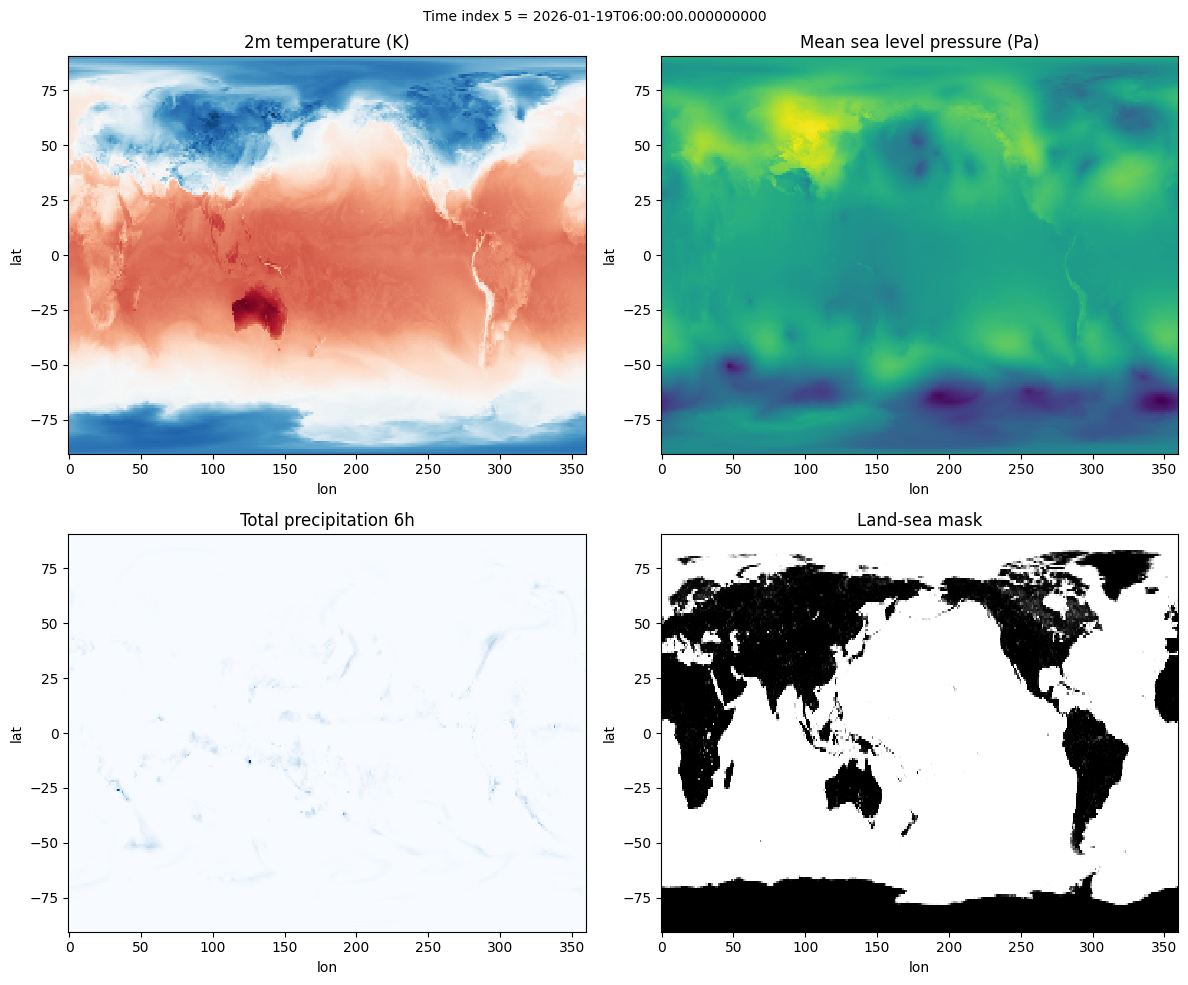

In [15]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

# Select which time step (and optionally which day) to plot
time_idx = 5
batch_idx = 0
# For 6-hourly data, 4 steps per day: set time_idx = day_idx * 4 to pick a day
# day_idx = 0
# time_idx = day_idx * 4

def get_2d(da, time_idx=0, batch_idx=0):
    """Extract 2D lat/lon slice from (batch, time, lat, lon) or (batch, time, level, lat, lon), or return 2D as-is."""
    a = np.asarray(da)
    if a.ndim == 2:
        return a
    if a.ndim == 4:
        return a[batch_idx, time_idx, :, :]
    if a.ndim == 5:
        return a[batch_idx, time_idx, 0, :, :]  # first pressure level
    return a.squeeze()

def get_coords(ds, use_xarray):
    if use_xarray:
        return ds["lat"].values, ds["lon"].values
    return ds.variables["lat"][:], ds.variables["lon"][:]

lat, lon = get_coords(ds, USE_XARRAY)

fig, axes = plt.subplots(2, 2, figsize=(12, 10), subplot_kw={"projection": None})

if USE_XARRAY:
    t2 = get_2d(ds["2m_temperature"], time_idx=time_idx, batch_idx=batch_idx)
    mslp = get_2d(ds["mean_sea_level_pressure"], time_idx=time_idx, batch_idx=batch_idx)
    precip = get_2d(ds["total_precipitation_6hr"], time_idx=time_idx, batch_idx=batch_idx)
    mask = get_2d(ds["land_sea_mask"], time_idx=time_idx, batch_idx=batch_idx)
else:
    t2 = get_2d(ds.variables["2m_temperature"][:], time_idx=time_idx, batch_idx=batch_idx)
    mslp = get_2d(ds.variables["mean_sea_level_pressure"][:], time_idx=time_idx, batch_idx=batch_idx)
    precip = get_2d(ds.variables["total_precipitation_6hr"][:], time_idx=time_idx, batch_idx=batch_idx)
    mask = get_2d(ds.variables["land_sea_mask"][:], time_idx=time_idx, batch_idx=batch_idx)

# Show selected time in figure title (if available)
if USE_XARRAY and "time" in ds.coords:
    t = ds["time"].values
    if time_idx < len(t):
        fig.suptitle(f"Time index {time_idx} = {t[time_idx]}", fontsize=10)
elif not USE_XARRAY and "time" in ds.variables and time_idx < ds.dimensions["time"].size:
    fig.suptitle(f"Time index {time_idx}", fontsize=10)

axes[0, 0].pcolormesh(lon, lat, t2, shading="auto", cmap="RdBu_r")
axes[0, 0].set_title("2m temperature (K)")
axes[0, 0].set_xlabel("lon")
axes[0, 0].set_ylabel("lat")

axes[0, 1].pcolormesh(lon, lat, mslp, shading="auto", cmap="viridis")
axes[0, 1].set_title("Mean sea level pressure (Pa)")
axes[0, 1].set_xlabel("lon")
axes[0, 1].set_ylabel("lat")

axes[1, 0].pcolormesh(lon, lat, precip, shading="auto", cmap="Blues")
axes[1, 0].set_title("Total precipitation 6h")
axes[1, 0].set_xlabel("lon")
axes[1, 0].set_ylabel("lat")

axes[1, 1].pcolormesh(lon, lat, mask, shading="auto", cmap="binary")
axes[1, 1].set_title("Land-sea mask")
axes[1, 1].set_xlabel("lon")
axes[1, 1].set_ylabel("lat")

plt.tight_layout()
plt.show()

## 5. Temperature on pressure levels (vertical slice)

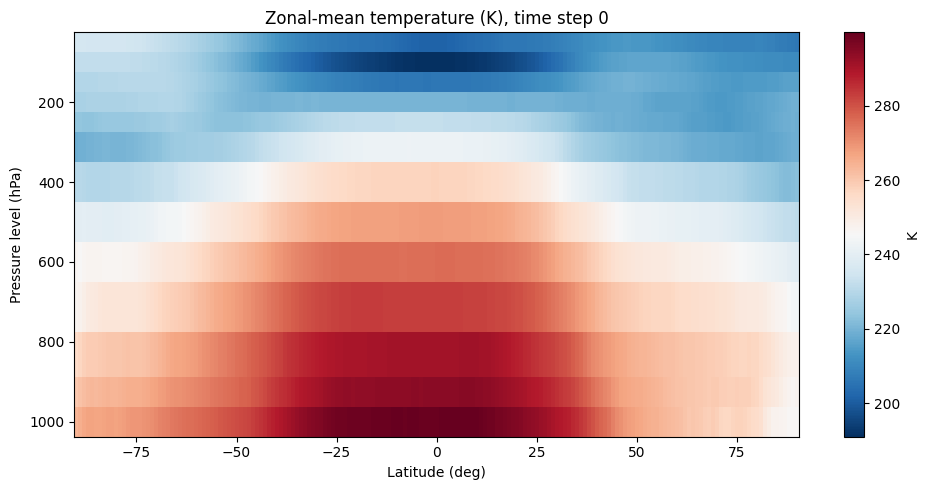

In [16]:
if USE_XARRAY:
    temp = ds["temperature"].values  # (batch, time, level, lat, lon)
    levels = ds["level"].values
else:
    temp = ds.variables["temperature"][:]  # (batch, time, level, lat, lon)
    levels = ds.variables["level"][:]

# Zonal mean at first time step: (level, lat)
temp_zonal = np.nanmean(temp[0, 0, :, :, :], axis=-1)

fig, ax = plt.subplots(figsize=(10, 5))
pc = ax.pcolormesh(lat, levels, temp_zonal, shading="auto", cmap="RdBu_r")
ax.set_ylabel("Pressure level (hPa)")
ax.set_xlabel("Latitude (deg)")
ax.set_title("Zonal-mean temperature (K), time step 0")
ax.invert_yaxis()
plt.colorbar(pc, ax=ax, label="K")
plt.tight_layout()
plt.show()

## 6. Close dataset (if using netCDF4)

In [1]:
ds.close()
print("Dataset closed.")

NameError: name 'ds' is not defined